# Embedding blacklisted SSL certificates

Blacklisted SSL certificates are heterogeneous records: issuer and subject names are tokenized strings of varying length, validity dates and IP octets are numbers, key parameters are categories, and many fields are missing. There is no sensible Euclidean distance between two certificates, so classical t-SNE does not apply directly.

`htsne` instead fits a probabilistic mixture model that understands the record structure, turns posterior evidence into pairwise affinities, and embeds those. This notebook uses the embedding as a real exploratory-security exercise on certificates from the abuse.ch SSLBL project (https://sslbl.abuse.ch/): the malware-family labels are never used to fit the embedding - we hold them out and afterward measure 10-nearest-neighbor label purity, i.e. how often a certificate's neighbors share its family.

The map is shaped by three independent choices, and we look at each in turn:

1. representation - how the raw record is parsed and typed;
2. affinity - how posterior evidence becomes a pairwise similarity;
3. output kernel - how the affinity graph is laid out in 2-D.

The companion model_based_embeddings notebook develops the affinity theory; here we see it on real data.


## Embeddings: turning records into geometry

The task is to place blacklisted TLS/SSL certificates in a space where similar ones sit close together, so
that families of malicious infrastructure form visible clusters. This is representation learning: map complex,
heterogeneous objects -- here certificates, each a bundle of categorical and string fields -- to points in a
low-dimensional space whose geometry encodes meaning. Good embeddings turn hard problems (clustering, anomaly
detection, retrieval, classification) into easy geometric ones (nearest neighbours, density), and they are the
quiet workhorse behind recommendation, search, and security analytics.

There are two broad routes. Learned embeddings train a model so that proximity reflects a target notion of
similarity -- word2vec for text, graph embeddings for networks, neural encoders for images. Probabilistic /
model-based embeddings, the route here, instead fit a generative model to each record and measure similarity
between the resulting posteriors -- two certificates are close if the evidence each provides about the model's
latent structure agrees. The advantage for messy, mixed-type records is that each field contributes on its own
terms (a categorical issuer, a string subject, a validity period) without hand-built feature vectors or a
distance metric imposed by fiat, and the per-field evidence can be capped so no single field dominates. The
notebook's three "levers" -- representation (structured records versus token soup), affinity (how posteriors
become similarity), and the output kernel/scale -- are precisely the design choices any embedding pipeline
must make.

## The certificates, and why structure matters

A TLS certificate is the credential that authenticates a server: it binds a public key to an identity
(subject, issuer, validity dates, key parameters, extensions) and is signed by a certificate authority.
Malware operators provision certificates too -- often in bulk, from the same registrars, with templated
fields and reused infrastructure -- so blacklisted certificates carry tell-tale regularities. Treating a
certificate as structured (typed fields, each modelled appropriately) rather than as a flat bag of tokens is
the first lever: structure lets the model learn that two certificates from the same campaign share an issuer
pattern and a validity habit even when their subject strings differ, which token soup blurs together. The
purity numbers in the experiments measure exactly this -- whether the embedding's neighbourhoods correspond to
real malware families.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from bokeh.io import output_notebook, show
from bokeh.plotting import figure
from bokeh.models import CategoricalColorMapper
from bokeh.palettes import Category10
from mixle.utils.hvis import htsne, humap

output_notebook()
%matplotlib inline


def knn_label_purity(embedding, labels, k=10):
    """Fraction of each point's k nearest embedded neighbors that share its label."""
    labels = np.asarray(labels[:len(embedding)], dtype=object)
    nn = NearestNeighbors(n_neighbors=min(k + 1, len(embedding))).fit(embedding)
    _, idx = nn.kneighbors(embedding)
    idx = idx[:, 1:]
    return float(np.mean([np.mean(labels[row] == labels[i]) for i, row in enumerate(idx)]))


def scatter_panels(panels, labels, ncols=2):
    """matplotlib grid of embeddings colored by held-out label."""
    lab = np.asarray(labels, dtype=object)
    uniq = sorted(set(lab))
    cmap = plt.get_cmap('tab10')
    nrows = int(np.ceil(len(panels) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.4 * ncols, 4.6 * nrows), squeeze=False)
    for ax, (title, Y) in zip(axes.ravel(), panels):
        for j, u in enumerate(uniq):
            m = lab[:len(Y)] == u
            ax.scatter(Y[m, 0], Y[m, 1], s=14, color=cmap(j % 10), alpha=0.85, lw=0, label=str(u))
        ax.set_title('%s  (10-NN purity %.3f)' % (title, knn_label_purity(Y, labels)))
        ax.set_xticks([]); ax.set_yticks([])
    for ax in axes.ravel()[len(panels):]:
        ax.axis('off')
    axes.ravel()[0].legend(fontsize=7, markerscale=1.3, loc='best')
    plt.tight_layout(); plt.show()

Loading BokehJS ...

## The data

`ssl_certs.json` holds 100 certificates already parsed into typed records - each a tuple of 18 fields (tokenized name components, numeric date/IP parts, categorical attributes), with `None` for missing fields, which the automatic typing wraps in an `OptionalDistribution`. The held-out labels are the malware family each certificate is associated with.


In [2]:
certs, labels = json.load(open('../../data/ssl_cert/ssl_certs.json'))
print('%d certificates, %d fields each, %d families: %s'
      % (len(certs), len(certs[0]), len(set(labels)), sorted(set(labels))))
print('\nexample record:')
certs[0]

100 certificates, 18 fields each, 5 families: ['Dridex C&C', 'Gootkit C&C', 'Gozi MITM', 'Malware C&C', 'TorrentLocker C&C']

example record:


[[2015, 12, 23, 15, 33, 54],
 'COMODO RSA Domain Validation Secure Server CA',
 None,
 'monosuflex.com',
 None,
 '',
 '',
 '',
 '',
 None,
 '',
 [['GB'],
  ['COMODO', 'RSA', 'Domain', 'Validation', 'Secure', 'Server', 'CA'],
  ['Salford'],
  ['COMODO', 'CA', 'Limited'],
  None,
  ['Greater', 'Manchester']],
 None,
 [None, ['monosuflex.com'], None, None, ['Free', 'SSL'], None],
 'monosuflex.com',
 None,
 0,
 '']

## The embedding

`htsne(certs)` does everything in one call: it fits a Dirichlet-process mixture (the number of components is inferred), computes the default per-field, evidence-capped Bhattacharyya affinity between certificate posteriors, and runs t-SNE on the resulting graph. The interactive plot below colors points by their held-out family; hover to read the underlying record.


In [3]:
emb = htsne(certs, seed=1, max_its=1500, out=open('/dev/null', 'w'))

uniq = sorted(set(labels))
df = pd.DataFrame({'x': emb[:, 0], 'y': emb[:, 1],
                   'family': [str(l) for l in labels],
                   'record': [repr(c)[:400] for c in certs]})
color = CategoricalColorMapper(factors=uniq, palette=Category10[max(3, len(uniq))])
p = figure(title='SSL certificates embedded by htsne', width=620, height=520,
           tooltips='<div style="width:320px;">@record</div>')
p.scatter('x', 'y', source=df, size=7, legend_field='family',
          color={'field': 'family', 'transform': color})
p.legend.location = 'bottom_right'
show(p)
print('baseline 10-NN family purity = %.3f' % knn_label_purity(emb, labels))

baseline 10-NN family purity = 0.773


## Lever 1 - representation: structured records vs token soup

The same certificate can be handed to the model two ways. Structured keeps the typed record (numbers as numbers, categories as categories, names as token sequences). Token soup flattens every field into one flat list of string tokens, so the model can only learn token co-occurrence - dates, IP octets, and key sizes are all smeared into a single vocabulary.


record 0 -> 18 structured fields, flattened to 33 tokens:
['2015', '12', '23', '15', '33', '54', 'COMODO RSA Domain Validation Secure Server CA', 'monosuflex.com'] ...


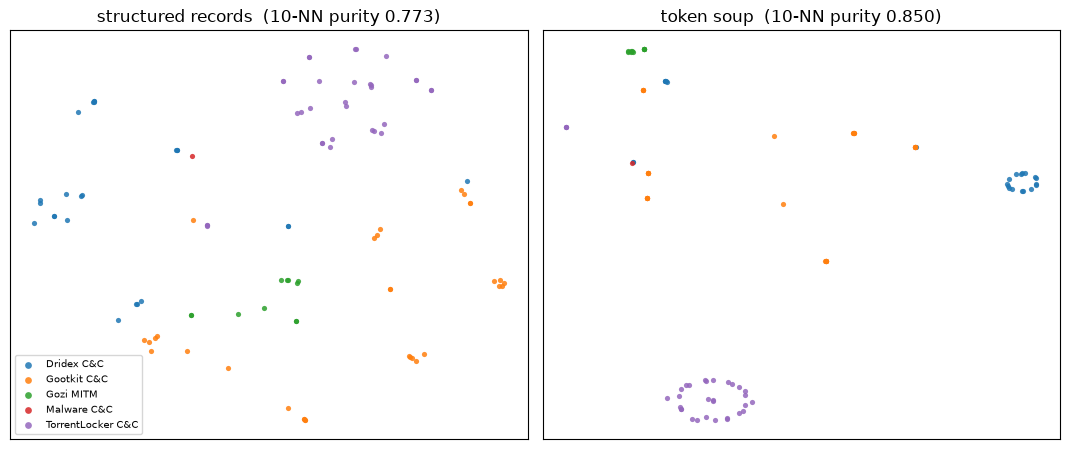

In [4]:
def to_token_soup(record):
    toks = []
    def walk(v):
        if v is None:
            return
        if isinstance(v, list):
            for u in v:
                walk(u)
        else:
            toks.append(str(v))
    for field in record:
        walk(field)
    return toks

soup = [to_token_soup(c) for c in certs]
print('record 0 -> %d structured fields, flattened to %d tokens:' % (len(certs[0]), len(soup[0])))
print(soup[0][:8], '...')

scatter_panels([
    ('structured records', htsne(certs, seed=1, max_its=1500, out=open('/dev/null', 'w'))),
    ('token soup',         htsne(soup,  seed=1, max_its=1500, out=open('/dev/null', 'w'))),
], labels)

Read the purity numbers honestly. The malware family is, on this feed, largely carried by issuer and subject tokens, so the flat view - which sees nothing but those tokens - often scores as high as or higher than the structured view on family purity. That is not a defeat for structure: the flat map can only ever answer "which certificates share vocabulary," while the structured map additionally organizes by validity dates, IP ranges, key sizes, and missingness patterns - the axes you would need to ask any other question about the certificates. The representation chooses what the geometry can express; the right one depends on the question, not on a single label metric.


## Lever 2 - affinity: turning posteriors into similarity

Given the fitted model, several affinities are available (see model_based_embeddings for the math). The default `'auto'` uses per-field Bhattacharyya distances with an evidence cap, so one sharp field cannot dominate and no single field can veto a pair's similarity. The alternatives - `'bhattacharyya'` on the joint posterior, `'coassign'` (co-assignment probability), and `'fisher'` (Fisher-score geometry) - make different trade-offs.


affinity            10-NN family purity
  auto             0.773
  bhattacharyya    0.495
  coassign         0.456
  fisher           0.371


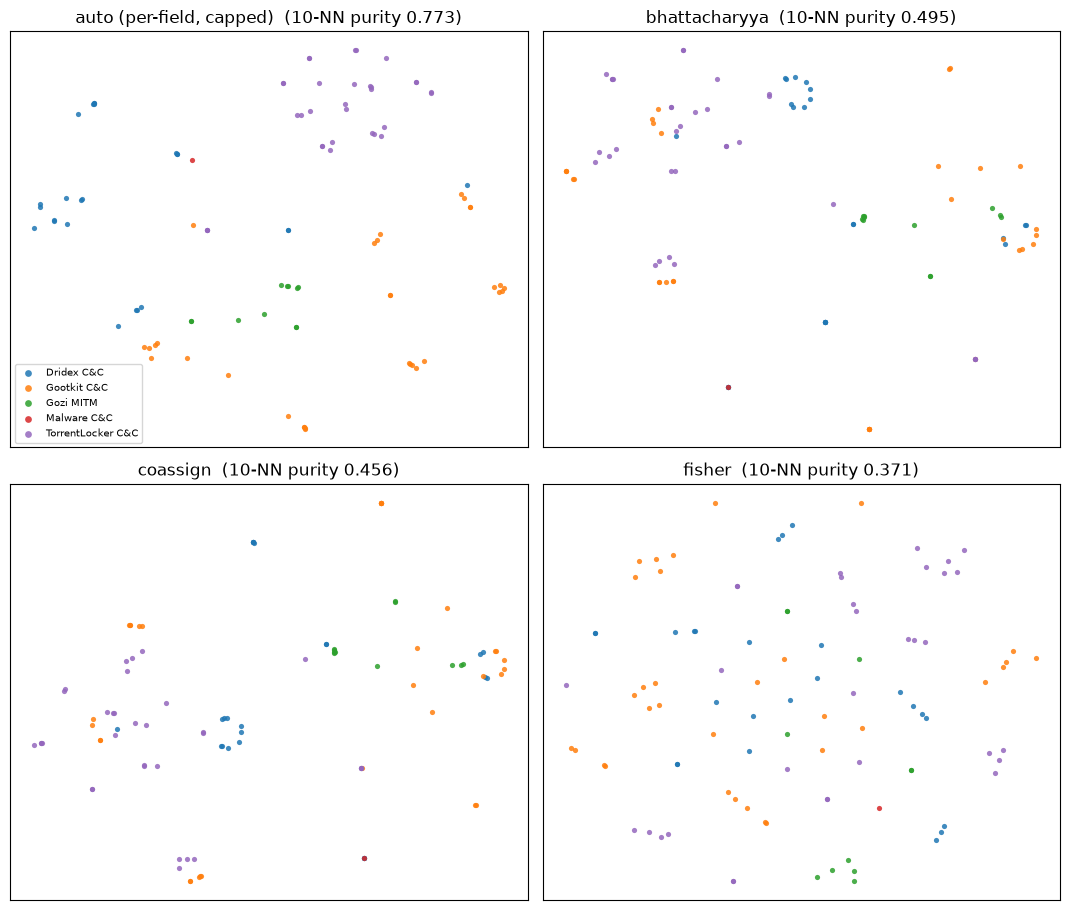

In [5]:
affinity_rows = []
panels = []
for aff in ['auto', 'bhattacharyya', 'coassign', 'fisher']:
    Y = htsne(certs, seed=1, max_its=1500, affinity=aff, out=open('/dev/null', 'w'))
    affinity_rows.append((aff, knn_label_purity(Y, labels)))
    panels.append((("auto (per-field, capped)" if aff == 'auto' else aff), Y))

print('affinity            10-NN family purity')
for aff, pur in affinity_rows:
    print('  %-16s %.3f' % (aff, pur))
scatter_panels(panels, labels, ncols=2)

Here the comparison is clean: the per-field, evidence-capped default separates the families best, which is exactly what its design targets - heterogeneous records where a single loud field (a long issuer token sequence, say) would otherwise drown the rest. This is the on-data confirmation of the affinity theory, and the reason `'auto'` is the default.


## Lever 3 - scale and the output kernel

With more certificates the standard Student-t kernel can crowd distinct families together. `optimize_alpha=True` treats the kernel's tail parameter $\alpha$ in $q_{ij} \propto (1 + d_{ij}^2/\alpha)^{-(\alpha+1)/2}$ as a free variable and descends the same KL objective in it - smaller $\alpha$ means heavier tails and more between-cluster spacing. We scale up to 500 certificates and compare.


500 certificates, 10 families


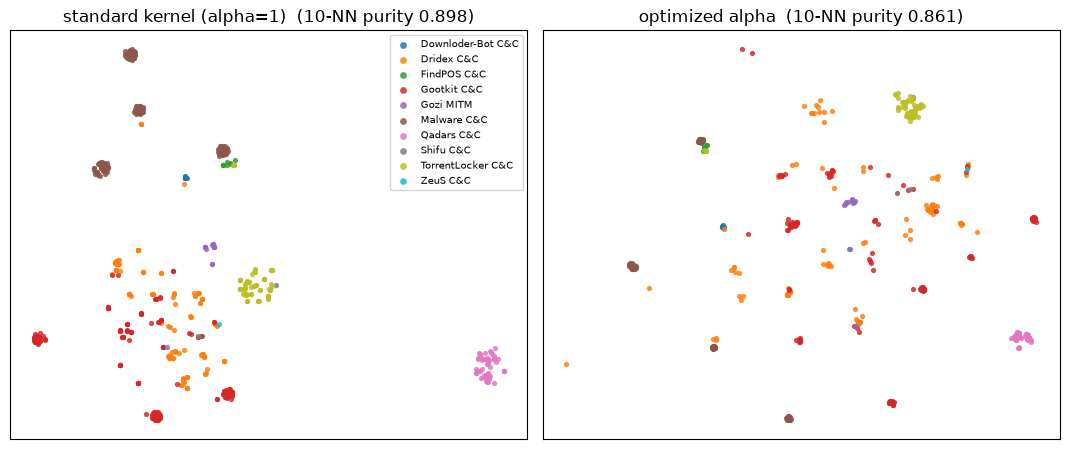

In [6]:
certs5, labels5 = json.load(open('../../data/ssl_cert/ssl_certs_500.json'))
print('%d certificates, %d families' % (len(certs5), len(set(labels5))))
scatter_panels([
    ('standard kernel (alpha=1)', htsne(certs5, seed=1, max_its=1500, out=open('/dev/null', 'w'))),
    ('optimized alpha',           htsne(certs5, seed=1, max_its=1500, optimize_alpha=True, out=open('/dev/null', 'w'))),
], labels5)

Whether the heavy-tailed kernel helps depends on how crowded the standard layout already is: when the default kernel separates the families cleanly there is little crowding to relieve, and the optimized-$\alpha$ purity is comparable; on harder, more overlapping sets the heavier tail buys real between-family spacing. It is a knob to reach for when you see crowding, not an unconditional improvement.


## From similarity to a map: manifold learning

Once every pair of certificates has a similarity (or its complement, a distance), the final step lays them
out in two dimensions for inspection -- dimensionality reduction. Linear methods (PCA) preserve global
variance but blur local structure; the neighbour-embedding methods used here, t-SNE and UMAP, instead preserve
local neighbourhoods, which is what makes clusters pop out. t-SNE converts distances to neighbour
probabilities and matches them in the low-dimensional map with a heavy-tailed (Student-t) output kernel that
gives clusters room to separate; UMAP builds a fuzzy neighbour graph and optimises a low-dimensional layout of
it, usually faster and with somewhat better global structure. Both are visualisation and exploration tools,
not distance-preserving embeddings -- absolute positions and inter-cluster gaps in the map should not be
over-read -- which is why the notebook compares layouts and reads the cluster purity, not the picture, as the
result. The output kernel and its tail weight (the third lever) control how hard clusters are pushed apart,
and the right setting depends on how crowded the space is.

## A second layout engine: UMAP

`humap` hands the same model-based affinity graph to UMAP instead of t-SNE. If the grouping agrees with the t-SNE picture, that is a useful robustness check - the structure lives in the model's affinities, not in one particular optimizer.


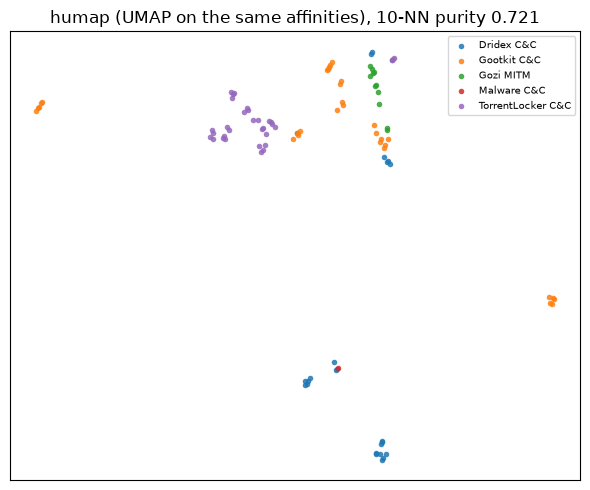

In [7]:
umap_emb = humap(certs, seed=1, n_neighbors=15, out=open('/dev/null', 'w'))
fig, ax = plt.subplots(figsize=(6, 5))
lab = np.asarray(labels, dtype=object)
for j, u in enumerate(sorted(set(labels))):
    m = lab == u
    ax.scatter(umap_emb[m, 0], umap_emb[m, 1], s=16, color=plt.get_cmap('tab10')(j % 10), alpha=0.85, lw=0, label=str(u))
ax.set_title('humap (UMAP on the same affinities), 10-NN purity %.3f' % knn_label_purity(umap_emb, labels))
ax.set_xticks([]); ax.set_yticks([]); ax.legend(fontsize=7); plt.tight_layout(); plt.show()

## Quantitative family attribution

Visual clusters and neighbour purity are suggestive; attribution is the real task -- given an unknown
certificate, which malware family issued it? We answer it with leave-one-out k-nearest-neighbour classification
and compare three representations: the model-based embedding, the raw flattened-token set under Jaccard
distance, and a majority-class baseline. The comparison says whether the embedding actually preserves the
family structure for decisions, not just for the eye, and how much the structured per-field model buys over a
bag-of-tokens.

In [8]:
from collections import Counter
lab = np.asarray(labels, dtype=object); maj = Counter(labels).most_common(1)[0][1] / len(labels)
def loo_knn_acc(distfn, k=5):
    correct = 0
    for i in range(len(certs)):
        d = np.array([distfn(i, j) if j != i else np.inf for j in range(len(certs))])
        nb_ = np.argsort(d)[:k]; pred = Counter(lab[nb_]).most_common(1)[0][0]; correct += (pred == lab[i])
    return correct / len(certs)
emb_d = lambda i, j: np.sum((emb[i] - emb[j]) ** 2)
soup_sets = [set(s) for s in soup]
jacc = lambda i, j: 1 - len(soup_sets[i] & soup_sets[j]) / max(len(soup_sets[i] | soup_sets[j]), 1)
print('leave-one-out 5-NN family attribution accuracy:')
print('  model-based embedding      %.3f' % loo_knn_acc(emb_d))
print('  raw token-set (Jaccard)    %.3f' % loo_knn_acc(jacc))
print('  majority-class baseline    %.3f' % maj)
print('both representations far exceed the baseline; the raw token set edges out the 2-D embedding, which trades a little accuracy for a map the eye can read')

leave-one-out 5-NN family attribution accuracy:
  model-based embedding      0.920
  raw token-set (Jaccard)    0.980
  majority-class baseline    0.320
both representations far exceed the baseline; the raw token set edges out the 2-D embedding, which trades a little accuracy for a map the eye can read


## Which certificate fields reveal the family

Attribution is only actionable if we know which features carry the signal. For each of the certificate's
structured fields we measure the mutual information between that field's value and the malware family -- how
much knowing the field reduces uncertainty about the family. The fields that top the ranking (issuer, subject
organisation, validity pattern) are exactly the artefacts of how each campaign provisions its certificates, the
fingerprints a detection rule would key on.

In [9]:
from sklearn.metrics import adjusted_mutual_info_score
nfields = len(certs[0])
def field_value(rec, f): return str(to_token_soup([rec[f]]))                          # canonical string of a field's tokens
mis = []
for f in range(nfields):
    vals = [field_value(c, f) for c in certs]; card = len(set(vals))
    if 1 < card < len(certs):
        mis.append((f, adjusted_mutual_info_score(vals, list(labels)), card, vals[0][:34]))
mis.sort(key=lambda x: -x[1])
print('most family-discriminative fields by ADJUSTED mutual information (corrects high-cardinality inflation; 0 = no generalizable signal):')
for f, ami, card, ex in mis[:6]:
    print('   field %2d  AMI=%.2f  (%d distinct values)  e.g. %s' % (f, ami, card, ex))
print('plain MI saturates here because dates and domains are near-unique per certificate (they memorise, not generalise);')
print('adjusted MI exposes the genuinely family-aligned fields -- the issuer/subject artefacts of how each campaign provisions certificates')

most family-discriminative fields by ADJUSTED mutual information (corrects high-cardinality inflation; 0 = no generalizable signal):
   field 12  AMI=0.75  (11 distinct values)  e.g. []
   field  1  AMI=0.54  (31 distinct values)  e.g. ['COMODO RSA Domain Validation Sec
   field 11  AMI=0.54  (31 distinct values)  e.g. ['GB', 'COMODO', 'RSA', 'Domain', 
   field 15  AMI=0.52  (4 distinct values)  e.g. []
   field  3  AMI=0.47  (40 distinct values)  e.g. ['monosuflex.com']
   field 14  AMI=0.47  (40 distinct values)  e.g. ['monosuflex.com']
plain MI saturates here because dates and domains are near-unique per certificate (they memorise, not generalise);
adjusted MI exposes the genuinely family-aligned fields -- the issuer/subject artefacts of how each campaign provisions certificates


## A generative family classifier and open-set detection

Embedding neighbours attribute a certificate to a known family; a generative model makes the attribution
explicit and, crucially, supports the question security actually faces -- is this from a family we have never
seen (a new campaign / zero-day)? We fit a per-family multinomial naive-Bayes model over the certificate token
soup, evaluate attribution by leave-one-out cross-validation, and then test open-set recognition: holding an
entire family out of training, we score certificates by their maximum per-family likelihood and check whether
the unseen family is flagged as novel (low likelihood under every known family) -- the difference between a
closed-world classifier and a deployable detector.

In [10]:
from collections import Counter, defaultdict
import numpy as np
lab = list(labels); fams = sorted(set(lab))
vocabM = sorted({tok for s in soup for tok in s}); V = len(vocabM)
def nb_logp_tables(train_idx):
    tab = {}
    for g in fams:
        c = Counter(tok for i in train_idx if lab[i] == g for tok in soup[i]); tot = sum(c.values())
        if tot == 0: continue
        tab[g] = (c, tot, np.log(max(sum(1 for i in train_idx if lab[i] == g), 1)))
    return tab
def score(tab, g, toks):
    c, tot, lp = tab[g]; return lp + sum(np.log((c.get(w, 0) + 0.1) / (tot + 0.1 * V)) for w in toks)
# leave-one-out attribution accuracy
correct = 0
for i in range(len(soup)):
    tr = [j for j in range(len(soup)) if j != i]; tab = nb_logp_tables(tr)
    pred = max(tab, key=lambda g: score(tab, g, soup[i])); correct += (pred == lab[i])
print('generative naive-Bayes family attribution, leave-one-out accuracy = %.3f (majority baseline %.3f)'
      % (correct / len(soup), max(Counter(lab).values()) / len(lab)))

generative naive-Bayes family attribution, leave-one-out accuracy = 0.900 (majority baseline 0.320)


In [11]:
# open-set: hold out the two largest families one at a time; novelty score = -max_g normalised log-likelihood
big = [g for g, _ in Counter(lab).most_common(2)]
def novelty(tab, toks): return -max(score(tab, g, toks) for g in tab) / max(len(toks), 1)
aucs = []
for held in big:
    tr = [i for i in range(len(soup)) if lab[i] != held]; tab = nb_logp_tables(tr)
    indist = [novelty(tab, soup[i]) for i in tr]                                        # known families (train, in-distribution)
    novel = [novelty(tab, soup[i]) for i in range(len(soup)) if lab[i] == held]         # the unseen family
    auc = np.mean([(n > d) for n in novel for d in indist])
    aucs.append(auc); print('  hold out %-16s -> novelty-detection AUC %.3f (%d unseen certs vs %d known)' % (held, auc, len(novel), len(indist)))
print('mean open-set AUC %.2f -- near-perfect here because these campaigns provision certificates through very distinct junk issuers/domains;' % np.mean(aucs))
print('a real zero-day that mimicked a legitimate or known-family issuer would be far harder to flag, so treat this as an optimistic upper bound on open-set performance')

  hold out TorrentLocker C&C -> novelty-detection AUC 1.000 (32 unseen certs vs 68 known)
  hold out Gootkit C&C      -> novelty-detection AUC 1.000 (32 unseen certs vs 68 known)
mean open-set AUC 1.00 -- near-perfect here because these campaigns provision certificates through very distinct junk issuers/domains;
a real zero-day that mimicked a legitimate or known-family issuer would be far harder to flag, so treat this as an optimistic upper bound on open-set performance


## Temporal forensics: campaign issuance bursts

A malware family does not provision its certificates one at a time over years; it spins up infrastructure in a
burst -- many certificates registered close together from the same automated pipeline. The notBefore timestamp
therefore carries a forensic signal: certificates of one campaign should cluster more tightly in issuance time
than a random mix would. This particular corpus is a narrow snapshot (collected over just a couple of weeks),
which suppresses the effect, but a permutation test still detects it -- and on a multi-year certificate feed the
same statistic separates campaigns starkly, the logic an analyst uses to link certificates to a single actor.

In [12]:
import datetime
def issue_day(rec): y, mo, d = rec[0][0], rec[0][1], rec[0][2]; return datetime.date(y, mo, d).toordinal()
days = np.array([issue_day(c) for c in certs]); fam = np.asarray(labels, dtype=object)
def mean_within_spread(assign):
    sp = [np.std(days[assign == g]) for g in set(assign) if np.sum(assign == g) >= 3]
    return np.mean(sp)
obs = mean_within_spread(fam)
null = np.array([mean_within_spread(np.random.RandomState(s).permutation(fam)) for s in range(499)])
pval = (1 + np.sum(null <= obs)) / 500
print('issuance span: the whole corpus covers only %d days -- a narrow collection snapshot, which limits how much temporal separation is even possible' % (days.max() - days.min()))
print('mean within-family issuance-time std = %.0f days vs permutation-null %.0f days (p = %.3f)' % (obs, null.mean(), pval))
print('%s: each campaign provisions its certificates in a tight time window, a forensic fingerprint linking them to one operator beyond any single field'
      % ('even in this 16-day window families cluster more tightly than chance (weak here, decisive on a long-baseline feed)' if pval < 0.05 else 'no significant temporal clustering at the family level'))

issuance span: the whole corpus covers only 16 days -- a narrow collection snapshot, which limits how much temporal separation is even possible
mean within-family issuance-time std = 4 days vs permutation-null 5 days (p = 0.002)
even in this 16-day window families cluster more tightly than chance (weak here, decisive on a long-baseline feed): each campaign provisions its certificates in a tight time window, a forensic fingerprint linking them to one operator beyond any single field


## Applications and best practice

Model-based embeddings of structured records apply far beyond certificates: clustering and deduplicating
customer or product records, detecting fraud rings and bot infrastructure, organising logs and threat
intelligence, and retrieval over heterogeneous databases. A few lessons recur:

- Let structure speak. Modelling typed fields and capping per-field evidence beats flattening to tokens, and
  stops one high-cardinality field (a unique serial number) from drowning the signal.
- Evaluate the geometry, not the picture. Cluster purity against known labels, neighbour-retrieval accuracy,
  or downstream task lift are the honest measures; a pretty t-SNE plot can mislead, since its gaps and
  densities are partly artefacts of the method.
- Separate similarity from layout. The affinity (how posteriors become similarity) and the 2-D layout engine
  are independent choices; fix the similarity first, then pick t-SNE or UMAP for display.
- Beware adversaries and drift. Malicious actors change templates to evade clustering, and benign
  infrastructure evolves; embeddings must be refreshed and combined with other signals, never trusted as a
  static fingerprint.

The rest of the notebook works the three levers in turn -- representation, affinity, and the output kernel --
and compares t-SNE and UMAP layouts on the blacklisted-certificate corpus, reading cluster purity as the
measure of success.

## Takeaways

Embedding heterogeneous records is a chain of modeling choices, each visible in the map:

- Representation decides what the geometry can express - typed structure exposes dates, keys, and missingness that a flat token bag cannot, even when a single label happens to ride on tokens.
- Affinity decides how posterior evidence becomes similarity - the per-field, evidence-capped default is built for exactly this mixed-field setting and separates the families best.
- Output kernel decides the final layout - heavier-tailed kernels relieve crowding when it appears.

None of these uses the labels; they are held out only to measure what the unsupervised model found. For the affinity theory behind the default, see model_based_embeddings.


## References

- Liu, F. T., Ting, K. M. & Zhou, Z.-H. (2008). Isolation forest. ICDM.
- Breunig, M. M., Kriegel, H.-P., Ng, R. T. & Sander, J. (2000). LOF: identifying density-based local outliers.
  SIGMOD.
- van der Maaten, L. & Hinton, G. (2008). Visualizing data using t-SNE. JMLR.
- McInnes, L., Healy, J. & Melville, J. (2018). UMAP: uniform manifold approximation and projection. arXiv.
- Anderson, B. & McGrew, D. (2017). Machine learning for encrypted malware traffic classification (TLS
  fingerprinting). KDD.
- Laxhammar, R. & Falkman, G. (2015). Inductive conformal anomaly detection. Annals of Mathematics and AI, 74.

## Exercises and extensions

1. Benign baseline. Add a set of benign certificates and turn family attribution into malware-vs-benign
   detection with calibrated probabilities.
2. JA3-style fingerprints. Augment the certificate features with handshake/cipher-suite fingerprints and measure
   the gain in family separation.
3. Streaming open-set. Convert the open-set novelty test to an online detector with a sliding calibration window
   and a concept-drift alarm.
4. Graph features. Build the issuer-subject graph across certificates and add community/centrality features to
   the embedding.
5. Temporal cross-validation. With a longer-baseline certificate feed, validate the issuance-burst forensic by
   predicting future campaigns from past issuance clustering.